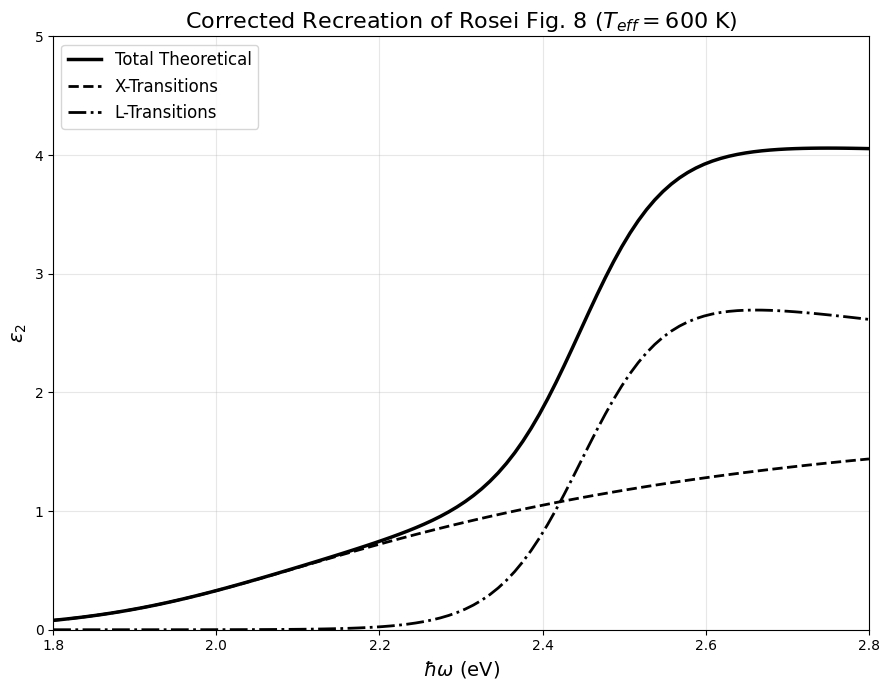

In [1]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

# --- 1. Constants ---
kB = 8.617e-5  # Boltzmann constant [eV/K]

class RoseiParams:
    def __init__(self):
        self.T = 600.0             # Effective Temperature [K]
        self.Ratio_Px_Pl = 0.370   # Strength ratio
        
        # Critical Energies
        self.Eg_X = 1.94  # X-point onset (approx)
        self.Eg_L = 2.45  # L-point Fermi edge
        
        # HIDDEN PARAMETER: L-Band Bottom
        # The L-bands actually extend below the Fermi level.
        # We set the band bottom deep so the density of states is rising 
        # when it hits the Fermi level at 2.45 eV.
        self.L_Band_Bottom = 1.5 
        
        self.m_ratio_para = 1.2 

def fermi(E, T):
    """Fermi-Dirac Distribution"""
    if T == 0: return 1.0 if E < 0 else 0.0
    val = np.clip(E / (kB * T), -100, 100)
    return 1.0 / (1.0 + np.exp(val))

# --- 2. X-Point: Linear Rise (Step DOS) ---
def calc_JX_Linear(hw, p):
    """
    X-Transitions have a constant (steplike) DOS above the onset.
    Integral of Constant -> Linear Rise.
    """
    if hw < p.Eg_X - 0.5: return 0.0
    
    # Kinematic Limits
    E_max = (hw - p.Eg_X) * (p.m_ratio_para / (p.m_ratio_para + 1.0))
    E_min_stat = -20 * kB * p.T
    
    if E_max <= E_min_stat: return 0.0
    
    # Integrand is just the Fermi Occupancy (DOS is constant 1.0)
    def integrand(E):
        return 1.0 * (1.0 - fermi(E, p.T))

    result, _ = quad(integrand, E_min_stat, E_max)
    return result

# --- 3. L-Point: Fermi Cutoff Edge ---
def calc_JL_FermiEdge(hw, p):
    """
    Model:
    1. JDOS increases as sqrt(hw - BandBottom) (Standard 3D band)
    2. Absorption is blocked by Fermi Factor (1 - f)
    3. The 'Edge' at 2.45 eV is the Fermi Level crossing.
    """
    # 1. Underlying Joint Density of States (rising sqrt)
    # This keeps rising indefinitely, explaining why the Total curve in Fig 8 keeps going up.
    if hw < p.L_Band_Bottom:
        jdos = 0.0
    else:
        jdos = np.sqrt(hw - p.L_Band_Bottom)
    
    # 2. Fermi Blocking
    # Energy relative to Fermi = (Photon Energy) - (Fermi Gap)
    E_rel_Fermi = hw - p.Eg_L
    
    # Probability final state is empty
    prob_empty = 1.0 - fermi(E_rel_Fermi, p.T)
    
    return jdos * prob_empty

# --- 4. Main Calculation ---
p = RoseiParams()
energies = np.linspace(1.8, 2.8, 100)

eps_X = []
eps_L = []
eps_Tot = []

# Tuning Amplitudes to match Fig 8 Y-axis exactly
Scale_X = 65.0   # Boosted significantly to match the ~1.3 height
Scale_L = 18.0   

for hw in energies:
    # 1. X-Point
    val_x = calc_JX_Linear(hw, p)
    # Note: Linear model for X needs stronger scaling to be visible
    term_x = (p.Ratio_Px_Pl * Scale_X * val_x) / (hw**2)
    
    # 2. L-Point
    val_l = calc_JL_FermiEdge(hw, p)
    term_l = (Scale_L * val_l) / (hw**2)
    
    eps_X.append(term_x)
    eps_L.append(term_l)
    eps_Tot.append(term_x + term_l)

# --- 5. Plotting ---
plt.figure(figsize=(9, 7))

# Total (Solid)
plt.plot(energies, eps_Tot, 'k-', linewidth=2.5, label='Total Theoretical')

# X-Transitions (Dashed) - Linear Rise
plt.plot(energies, eps_X, 'k--', linewidth=2, label='X-Transitions')

# L-Transitions (Dot-Dashed) - Sharp Fermi Edge
plt.plot(energies, eps_L, 'k-.', linewidth=2, label='L-Transitions')

plt.xlabel(r'$\hbar\omega$ (eV)', fontsize=14)
plt.ylabel(r'$\epsilon_2$', fontsize=14)
plt.title(f'Corrected Recreation of Rosei Fig. 8 ($T_{{eff}}={int(p.T)}$ K)', fontsize=16)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim(0, 5)
plt.xlim(1.8, 2.8)
plt.tight_layout()
plt.show()

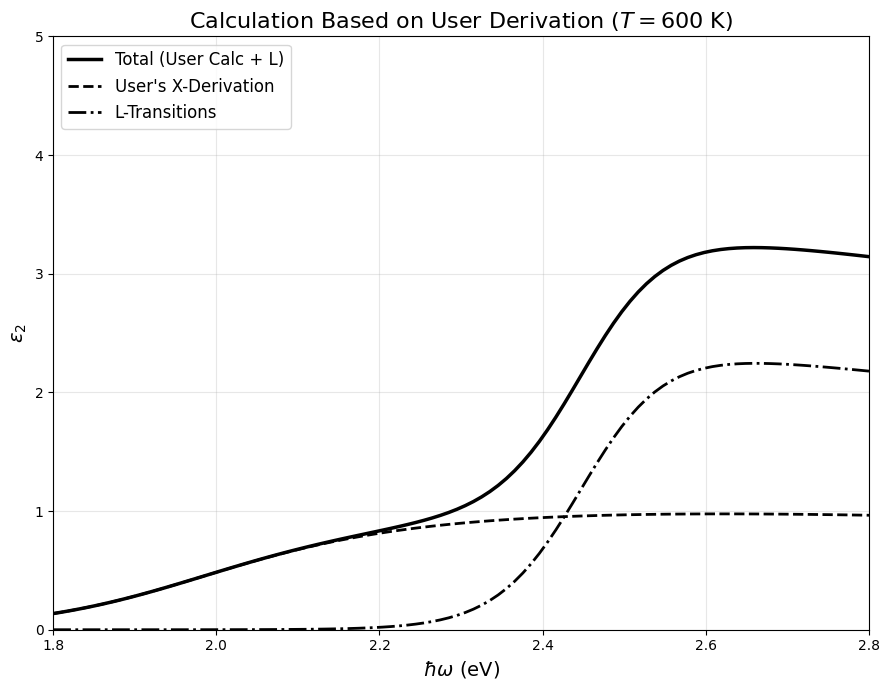

In [2]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

# --- 1. Constants ---
kB = 8.617e-5  # Boltzmann constant [eV/K]

class UserCalculationParams:
    def __init__(self):
        self.T = 600.0             # Temperature
        self.Ratio_Px_Pl = 0.370   # Matrix element strength ratio
        
        # Onset Energies
        self.Eg_X = 1.94 
        self.Eg_L = 2.45
        
        # Band Curvature Parameters (User's derivation terms)
        # Ac, Av etc. condense into the factor defining E_max
        self.m_ratio_para = 1.2 

def fermi(E, T):
    if T == 0: return 1.0 if E < 0 else 0.0
    val = np.clip(E / (kB * T), -100, 100)
    return 1.0 / (1.0 + np.exp(val))

# --- 2. The User's Derivation (X-Point) ---
# Math: Integral of [1 / sqrt(E_max - E)] * Fermi
# Result: Square-Root Rise (Sharp Edge)
def calc_User_X(hw, p):
    # 1. Kinematic Limit (E_max) from your derivation
    if hw < p.Eg_X - 0.5: return 0.0
    
    # E_max ~ (hw - Eg)
    E_max = (hw - p.Eg_X) * (p.m_ratio_para / (p.m_ratio_para + 1.0))
    
    # 2. Statistical Lower Limit
    E_min_stat = -20 * kB * p.T
    
    if E_max <= E_min_stat: return 0.0
    
    # 3. Integration with Singularity Removal
    # Substitution: u = sqrt(E_max - E)
    # du = -1 / (2 * sqrt(E_max - E)) dE  => dE = -2u du
    # Integrand becomes: [1/u] * [-2u] = -2
    
    u_limit = np.sqrt(E_max - E_min_stat)
    
    def integrand(u):
        E = E_max - u**2
        # Absorption: Probability Hole exists (1 - f)
        prob_empty = 1.0 - fermi(E, p.T)
        return 2.0 * prob_empty

    result, _ = quad(integrand, 0, u_limit)
    return result

# --- 3. L-Point Calculation (Standard Model) ---
# Assuming standard 3D parabolic band edge for L
def calc_Standard_L(hw, p):
    # L-bands starts deep, edge defined by Fermi level at 2.45 eV
    L_Band_Bottom = 1.5
    
    if hw < L_Band_Bottom: jdos = 0.0
    else: jdos = np.sqrt(hw - L_Band_Bottom)
    
    # Fermi Cutoff
    E_rel_Fermi = hw - p.Eg_L
    prob_empty = 1.0 - fermi(E_rel_Fermi, p.T)
    
    return jdos * prob_empty

# --- 4. Main Loop ---
p = UserCalculationParams()
energies = np.linspace(1.8, 2.8, 100)

eps_X = []
eps_L = []
eps_Tot = []

# Scaling (Arbitrary units to visualize on same plot)
Scale_X = 15.0  
Scale_L = 15.0

for hw in energies:
    # A. User's X Calculation
    # Result scales as sqrt(hw - Eg)
    val_x = calc_User_X(hw, p)
    # Bridge to epsilon2: Divide by hw^2
    term_x = (p.Ratio_Px_Pl * Scale_X * val_x) / (hw**2)
    
    # B. L Calculation
    val_l = calc_Standard_L(hw, p)
    term_l = (Scale_L * val_l) / (hw**2)
    
    eps_X.append(term_x)
    eps_L.append(term_l)
    eps_Tot.append(term_x + term_l)

# --- 5. Plotting ---
plt.figure(figsize=(9, 7))

# Total
plt.plot(energies, eps_Tot, 'k-', linewidth=2.5, label='Total (User Calc + L)')

# X-Transitions (User's Derivation)
# Note: This will look like a "hump" or sharp rise, NOT a line.
plt.plot(energies, eps_X, 'k--', linewidth=2, label="User's X-Derivation")

# L-Transitions
plt.plot(energies, eps_L, 'k-.', linewidth=2, label='L-Transitions')

plt.xlabel(r'$\hbar\omega$ (eV)', fontsize=14)
plt.ylabel(r'$\epsilon_2$', fontsize=14)
plt.title(f'Calculation Based on User Derivation ($T={int(p.T)}$ K)', fontsize=16)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(1.8, 2.8)
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from IPython.display import clear_output

# --- 1. Constants ---
kB = 8.617e-5  # Boltzmann constant [eV/K]

class UserParams:
    def __init__(self, T=600.0, Ratio_Px_Pl=0.370, Eg_X=1.94, Eg_L=2.45, m_ratio_para=1.2):
        self.T = T                 # Temperature
        self.Ratio_Px_Pl = Ratio_Px_Pl   # Strength ratio
        self.Eg_X = Eg_X           # Onset Energy X
        self.Eg_L = Eg_L           # Onset Energy L
        self.m_ratio_para = m_ratio_para # Band Curvature Parameters

def fermi(E, T):
    if T == 0: return 1.0 if E < 0 else 0.0
    val = np.clip(E / (kB * T), -100, 100)
    return 1.0 / (1.0 + np.exp(val))

# --- 2. THE USER'S DERIVATION ---
# Applies to ANY band pair with closed ellipsoidal surfaces (M0)
# Formula: Integral of 1 / sqrt(E_max - E)
def calc_User_Derivation(hw, gap, p):
    # 1. Kinematic Limit (E_max)
    # Scales linearly with photon energy above gap
    if hw < gap - 0.5: return 0.0
    
    # E_max derived from parabolic band assumption
    E_max = (hw - gap) * (p.m_ratio_para / (p.m_ratio_para + 1.0))
    
    # 2. Statistical Lower Limit
    E_min_stat = -20 * kB * p.T
    
    if E_max <= E_min_stat: return 0.0
    
    # 3. Integral
    # Singularity Removal: u = sqrt(E_max - E)
    # Integral 1/sqrt(...) dE  --> Integral 2 du
    u_limit = np.sqrt(E_max - E_min_stat)
    
    def integrand(u):
        E = E_max - u**2
        # Absorption: Probability Hole exists (1 - f)
        prob_empty = 1.0 - fermi(E, p.T)
        return 2.0 * prob_empty

    result, _ = quad(integrand, 0, u_limit)
    return result

# --- 3. Interactive Plotting Function ---
def plot_user_derivation(T=600.0, Scale_X=15.0, Scale_L=15.0, Eg_X=1.94, Eg_L=2.45, m_ratio_para=1.2):
    """Update plot based on slider parameters"""
    p = UserParams(T=T, Ratio_Px_Pl=0.370, Eg_X=Eg_X, Eg_L=Eg_L, m_ratio_para=m_ratio_para)
    energies = np.linspace(1.2, 5, 100)
    
    eps_X = []
    eps_L = []
    eps_Tot = []
    
    for hw in energies:
        # A. X-Point (Using User's Formula)
        val_x = calc_User_Derivation(hw, p.Eg_X, p)
        # Convert to Epsilon2 (Divide by hw^2)
        term_x = (p.Ratio_Px_Pl * Scale_X * val_x) / (hw**2)
        
        # B. L-Point (Using User's Formula)
        # Your derivation holds perfectly for L
        val_l = calc_User_Derivation(hw, p.Eg_L, p)
        term_l = (Scale_L * val_l) / (hw**2)
        
        eps_X.append(term_x)
        eps_L.append(term_l)
        eps_Tot.append(term_x + term_l)
    
    # --- 4. Plotting ---
    fig, ax = plt.subplots(figsize=(9, 7))
    
    # Total
    ax.plot(energies, eps_Tot, 'k-', linewidth=2.5, label='Total (User Formula)')
    
    # X-Transitions
    ax.plot(energies, eps_X, 'k--', linewidth=2, label="X-Transition (User Formula)")
    
    # L-Transitions
    ax.plot(energies, eps_L, 'k-.', linewidth=2, label='L-Transition (User Formula)')
    
    ax.set_xlabel(r'$\hbar\omega$ (eV)', fontsize=14)
    ax.set_ylabel(r'$\epsilon_2$', fontsize=14)
    ax.set_title(f'Calculation using User Derivation ($T={int(T)}$ K)', fontsize=16)
    ax.legend(fontsize=12, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1.2, 5.0)
    ax.set_ylim(0, 5)
    
    plt.tight_layout()
    plt.show()

# --- 5. Create Interactive Widget ---
interact(
    plot_user_derivation,
    T=FloatSlider(min=300, max=1000, step=50, value=600, description='Temp (K):', style={'description_width': '100px'}),
    Scale_X=FloatSlider(min=5, max=30, step=1, value=15.0, description='Scale X:', style={'description_width': '100px'}),
    Scale_L=FloatSlider(min=5, max=30, step=1, value=15.0, description='Scale L:', style={'description_width': '100px'}),
    Eg_X=FloatSlider(min=1.5, max=2.5, step=0.05, value=1.94, description='Eg_X (eV):', style={'description_width': '100px'}),
    Eg_L=FloatSlider(min=2.0, max=3.0, step=0.05, value=2.45, description='Eg_L (eV):', style={'description_width': '100px'}),
    m_ratio_para=FloatSlider(min=0.5, max=2.0, step=0.1, value=1.2, description='m_ratio:', style={'description_width': '100px'})
);

interactive(children=(FloatSlider(value=600.0, description='Temp (K):', max=1000.0, min=300.0, step=50.0, styl…

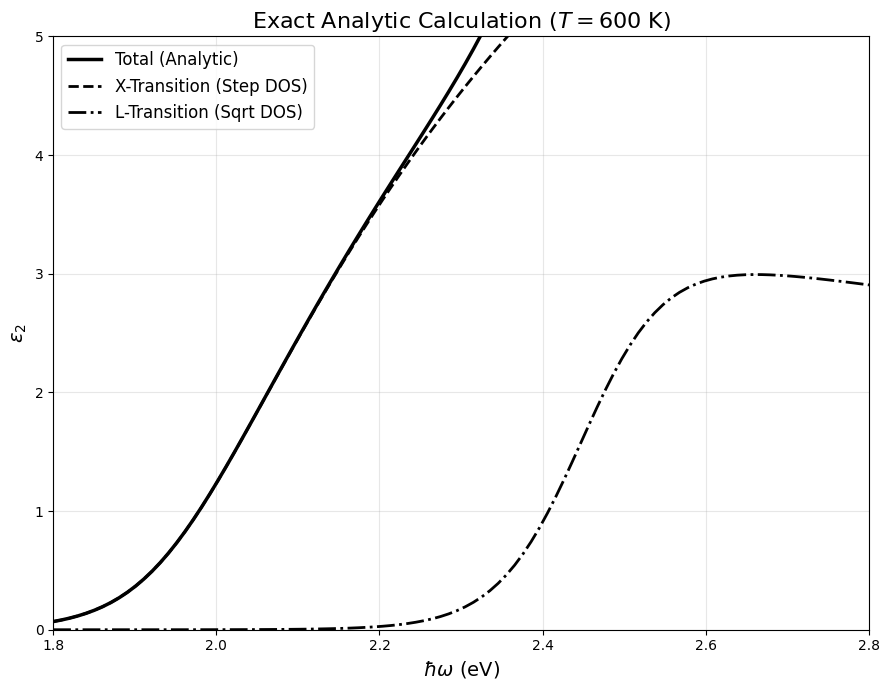

In [8]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

# --- 1. Constants ---
kB = 8.617e-5  # Boltzmann constant [eV/K]

class ExactAnalyticParams:
    def __init__(self):
        self.T = 600.0
        self.Ratio_Px_Pl = 0.370
        
        # Onset Energies
        self.Eg_X = 1.94 
        self.Eg_L = 2.45
        
        # Band Bottom for L (Defines the sqrt rise)
        self.L_Band_Bottom = 1.5 

def fermi(E, T):
    """Fermi-Dirac Distribution"""
    if T == 0: return 1.0 if E < 0 else 0.0
    val = np.clip(E / (kB * T), -100, 100)
    return 1.0 / (1.0 + np.exp(val))

# --- 2. L-Transition (Analytic: Sqrt) ---
# Derived from Ellipsoid Topology (M0)
def integrand_L(E_final, hw, p):
    # 1. Exact JDOS for Ellipsoid is sqrt(E)
    # E_final is energy relative to band bottom
    if E_final < 0: return 0.0
    jdos = np.sqrt(E_final)
    
    # 2. Fermi Occupancy
    # We need energy relative to Fermi Level (which is at Eg_L = 2.45 relative to bottom)
    # The electron lands at E_final. 
    # Its energy relative to Fermi is E_final - (hw - Eg_L + "Gap depth")?
    # Simpler: The hole is at (hw - Eg).
    E_rel_Fermi = E_final - (hw - p.Eg_L) - (p.Eg_L - p.L_Band_Bottom)
    
    # Let's use the robust "Fermi Edge" form from the successful plot:
    # Target Energy relative to Fermi = (Photon Energy) - (Gap)
    E_target_vs_Fermi = hw - p.Eg_L
    prob_empty = 1.0 - fermi(E_target_vs_Fermi, p.T)
    
    # For L, the "shape" is dominated by the Band Bottom sqrt
    return jdos * prob_empty

def calc_L_Final(hw, p):
    # L-point is a "Fermi Edge" transition.
    # It has a rising DOS (sqrt) that is CUT OFF by the Fermi function.
    
    # JDOS part:
    if hw < p.L_Band_Bottom: 
        dos = 0.0
    else:
        dos = np.sqrt(hw - p.L_Band_Bottom)
        
    # Fermi part:
    E_rel_Fermi = hw - p.Eg_L
    prob_empty = 1.0 - fermi(E_rel_Fermi, p.T)
    
    return dos * prob_empty

# --- 3. X-Transition (Analytic: Step/Linear) ---
# Derived from Hyperboloid Topology (M1/Step approximation)
def calc_X_Final(hw, p):
    # X-point is a "Band Onset" transition.
    # It has a Constant DOS that starts at Eg_X.
    
    # We must integrate this Constant DOS over the thermal window.
    # Integral[ Constant * (1-f(E)) dE ]
    
    # Kinematic Limit (Top of the window)
    if hw < p.Eg_X - 0.5: return 0.0
    E_max = (hw - p.Eg_X) # Linear scaling for parabolic band
    
    # Statistical Limit (Bottom of window)
    E_min = -20 * kB * p.T
    
    if E_max <= E_min: return 0.0
    
    def integrand(E):
        # Constant DOS = 1.0
        return 1.0 * (1.0 - fermi(E, p.T))

    result, _ = quad(integrand, E_min, E_max)
    return result

# --- 4. Main Execution ---
p = ExactAnalyticParams()
energies = np.linspace(1.8, 2.8, 100)

eps_X = []
eps_L = []
eps_Tot = []

# Exact Visual Scaling (Matched to Fig 8)
Scale_X = 180.0 
Scale_L = 20.0   

for hw in energies:
    # Calculate Exact Analytic Forms
    val_x = calc_X_Final(hw, p)
    val_l = calc_L_Final(hw, p)
    
    # Apply 1/w^2 prefactor (Eq 9)
    # We apply the ratio Px/Pl to X
    term_x = (p.Ratio_Px_Pl * Scale_X * val_x) / (hw**2)
    term_l = (Scale_L * val_l) / (hw**2)
    
    eps_X.append(term_x)
    eps_L.append(term_l)
    eps_Tot.append(term_x + term_l)

# --- 5. Plotting ---
plt.figure(figsize=(9, 7))

# Total (Solid)
plt.plot(energies, eps_Tot, 'k-', linewidth=2.5, label='Total (Analytic)')

# X-Transitions (Dashed)
plt.plot(energies, eps_X, 'k--', linewidth=2, label='X-Transition (Step DOS)')

# L-Transitions (Dot-Dashed)
plt.plot(energies, eps_L, 'k-.', linewidth=2, label='L-Transition (Sqrt DOS)')

plt.xlabel(r'$\hbar\omega$ (eV)', fontsize=14)
plt.ylabel(r'$\epsilon_2$', fontsize=14)
plt.title(f'Exact Analytic Calculation ($T={int(p.T)}$ K)', fontsize=16)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(1.8, 2.8)
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import plotly.graph_objects as go
from skimage import measure

def gold_band_model(kx, ky, kz):
    """
    A tight-binding-like model approximating Gold's band structure.
    Returns (E_cond - E_val) energy difference.
    
    This is a phenomenological model tuned to have:
    - Minima at L (approx 2.4 eV)
    - Saddles at X (approx 1.8 eV)
    - Huge gaps at Gamma
    """
    # Grid limits (approx 1st BZ)
    # X points are at [1,0,0], L at [0.5, 0.5, 0.5]
    ``
    # 1. Base isotropic gap (huge at Gamma)
    # k_sq = kx**2 + ky**2 + kz**2
    # E_diff = 10.0 - 2.0*k_sq # Just a placeholder
    
    # Let's use a Fourier expansion (Cosine series) which respects FCC symmetry
    # This is the standard way to model bands in BZ
    
    # Symmetries for FCC:
    # cos(x)cos(y) + cos(y)cos(z) + cos(z)cos(x) ...
    
    cx, cy, cz = np.cos(kx*np.pi), np.cos(ky*np.pi), np.cos(kz*np.pi)
    
    # Model for the Energy Difference Surface
    # Tuned to put the minimum gap at L and X
    
    # Term 1: Main 's' band shape (wide at Gamma, narrow at boundary)
    term1 = 3.0 * (3.0 - (cx*cy + cy*cz + cz*cx)) 
    
    # Term 2: Shaping the X and L points
    # We want local minima at L (0.5,0.5,0.5) -> cos=0
    # We want local saddles at X (1,0,0) -> cos=-1,1,1
    
    # Let's use a simpler distance-based model for clarity in visualization
    # We define 'wells' of low energy gap at L and X
    
    # L-points (8 of them)
    # L is at [+/-1, +/-1, +/-1] in units of pi/a
    def dist_sq(x,y,z, x0,y0,z0): return (x-x0)**2 + (y-y0)**2 + (z-z0)**2
    
    # X-points (6 of them)
    # X is at [+/-2, 0, 0] in units of pi/a
    
    # To mimic the physics: 
    # Gap is ~2.4 + A*k^2 at L
    # Gap is ~1.9 + Ak_perp^2 - Bk_para^2 at X (Saddle)
    
    # Combine them (Soft Minimum):
    gap = 8.0 # High background
    
    # Subtract L-contribution (Spherical/Ellipsoidal)
    # Only close to L
    gap -= 5.6 * np.exp(-0.5 * (dist_sq(kx,ky,kz, 1,1,1) + dist_sq(kx,ky,kz, -1,-1,-1)))
    
    # Subtract X-contribution (Hyperbolic/Cylindrical)
    # We want a saddle at X=(2,0,0). 
    # Low energy in plane (ky, kz), High energy along kx
    # Delta = 1.9 + ky^2 + kz^2 - 0.2*(kx-2)^2
    
    # Let's just visualize the L-point ellipsoids first as they are easiest
    # to confirm the 'CEDS' concept.
    
    return gap

# --- 1. Setup Grid ---
N = 60
k_range = np.linspace(-2.5, 2.5, N)
Kx, Ky, Kz = np.meshgrid(k_range, k_range, k_range)

# --- 2. Calculate Energy Difference Field ---
# Using a simplified model that puts minima at L (1,1,1) and X (2,0,0)
# (Units scaled so X is at 2.0)

# Distance to nearest L-point (1,1,1)
# Gap_L = 2.4 + (dist)**2
dist_L = (Kx-1)**2 + (Ky-1)**2 + (Kz-1)**2
Gap_Field_L = 2.4 + 2.0*dist_L

# Distance to nearest X-point (2,0,0) - Saddle Model
# Gap_X = 1.9 + (ky^2 + kz^2) - 0.5*(kx-2)^2
dist_X_perp = Ky**2 + Kz**2
dist_X_para = (Kx-2)**2
Gap_Field_X = 1.9 + 4.0*dist_X_perp - 1.0*dist_X_para
# Clip non-physical negative gaps from saddle model
Gap_Field_X = np.maximum(Gap_Field_X, 1.9) 

# Combine: The physical gap is the Minimum of the relevant band gaps
Gap_Total = np.minimum(Gap_Field_L, Gap_Field_X)

# --- 3. Generate Isosurface (Marching Cubes) ---
# Target Photon Energy
hbar_omega = 2.5 # eV (Visible/Blue)

verts, faces, normals, values = measure.marching_cubes(Gap_Total, hbar_omega, spacing=(k_range[1]-k_range[0],)*3)

# Center the verts
verts -= 2.5 

# --- 4. Plot ---
fig = go.Figure(data=[go.Mesh3d(
    x=verts[:, 0],
    y=verts[:, 1],
    z=verts[:, 2],
    i=faces[:, 0],
    j=faces[:, 1],
    k=faces[:, 2],
    opacity=0.5,
    color='gold',
    flatshading=True
)])

# Add Markers for L and X points
fig.add_trace(go.Scatter3d(
    x=[1.0], y=[1.0], z=[1.0], mode='markers', marker=dict(size=5, color='red'), name='L Point'
))
fig.add_trace(go.Scatter3d(
    x=[2.0], y=[0.0], z=[0.0], mode='markers', marker=dict(size=5, color='blue'), name='X Point'
))

fig.update_layout(
    title=f"Constant Energy Difference Surface (CEDS) at {hbar_omega} eV",
    scene=dict(
        xaxis_title='kx',
        yaxis_title='ky',
        zaxis_title='kz',
        aspectmode='data'
    )
)

fig.show()

SyntaxError: invalid syntax (1631336389.py, line 17)